# Assignment 6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches  
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# *Part 1: Data Extraction and Visualization* 

In [2]:
def parse_txt(file_name):   
    with open(f'gene_expression/{file_name}') as file:
        values = np.array([line.strip() for line in file.readlines()])     
        return values

In [3]:
gene1 = parse_txt('gene1.txt')
gene2 = parse_txt('gene2.txt')
cell_states = parse_txt('cell_states.txt')

df = pd.DataFrame({'gene1': gene1, 'gene2': gene2, 'cell_state':cell_states})
df = df.apply(pd.to_numeric)
df

,gene1,gene2,cell_state
0,0.4128,0.2915,0
1,1.2991,1.0242,0
2,1.2214,1.0102,0
3,1.0570,0.6534,0
4,1.1207,0.7288,0
...,...,...,...
1800,0.7224,0.7198,1
1801,0.3948,0.4226,0
1802,1.1552,1.1297,0
1803,1.0432,0.8903,1


In [4]:
X = df[['gene1', 'gene2']]
y = df['cell_state']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=['gene1', 'gene2'], index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=['gene1', 'gene2'], index=X_test.index)

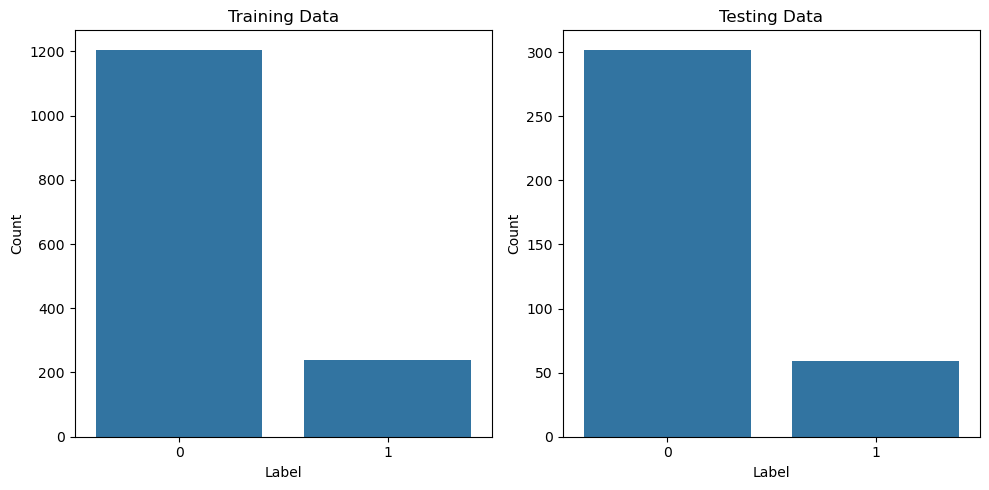

In [5]:
y_train_df = pd.DataFrame({'Cell State':y_train})
y_test_df = pd.DataFrame({'Cell State':y_test})
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

sns.countplot(x='Cell State', data=y_train_df, ax=ax[0])
ax[0].set_title('Training Data')
ax[0].set_xlabel('Label')
ax[0].set_ylabel('Count')

sns.countplot(x='Cell State', data=y_test_df, ax=ax[1])
ax[1].set_title('Testing Data')
ax[1].set_xlabel('Label')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

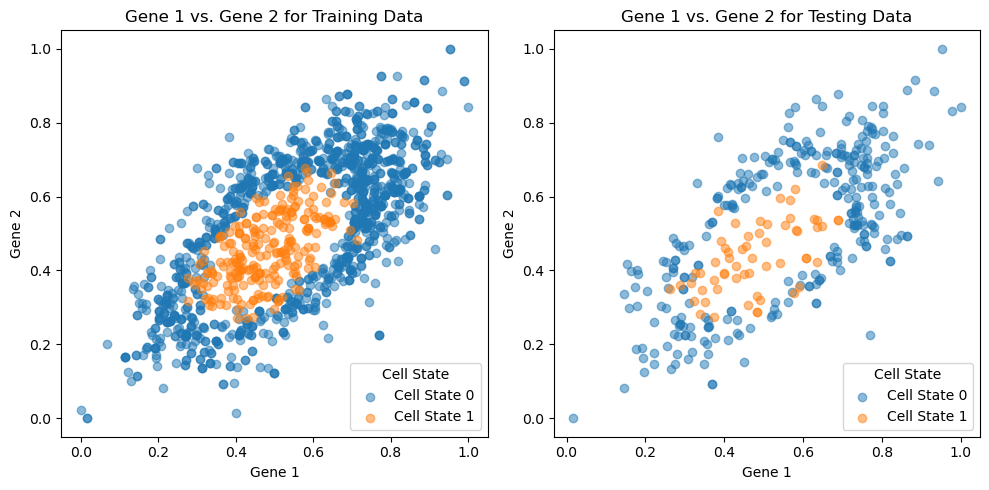

In [6]:
train_plot_data = X_train.copy()
train_plot_data['Label'] = y_train
train_plot_data = train_plot_data.reset_index()
test_plot_data = X_test.copy()
test_plot_data['Label'] = y_test
test_plot_data = test_plot_data.reset_index()


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

for label in [0,1]:
    train_label_data = train_plot_data[train_plot_data['Label'] == label]
    test_label_data = test_plot_data[test_plot_data['Label'] == label]
    ax[0].scatter(train_label_data['gene1'], train_label_data['gene2'], label=f'Cell State {label}', alpha=0.5)
    ax[1].scatter(test_label_data['gene1'], test_label_data['gene2'], label=f'Cell State {label}', alpha=0.5)

ax[0].set_title("Gene 1 vs. Gene 2 for Training Data")
ax[0].set_xlabel('Gene 1')
ax[0].set_ylabel('Gene 2')
ax[0].legend(title='Cell State', loc='lower right')

ax[1].set_title("Gene 1 vs. Gene 2 for Testing Data")
ax[1].set_xlabel('Gene 1')
ax[1].set_ylabel('Gene 2')
ax[1].legend(title='Cell State', loc='lower right')

plt.tight_layout()
plt.show()

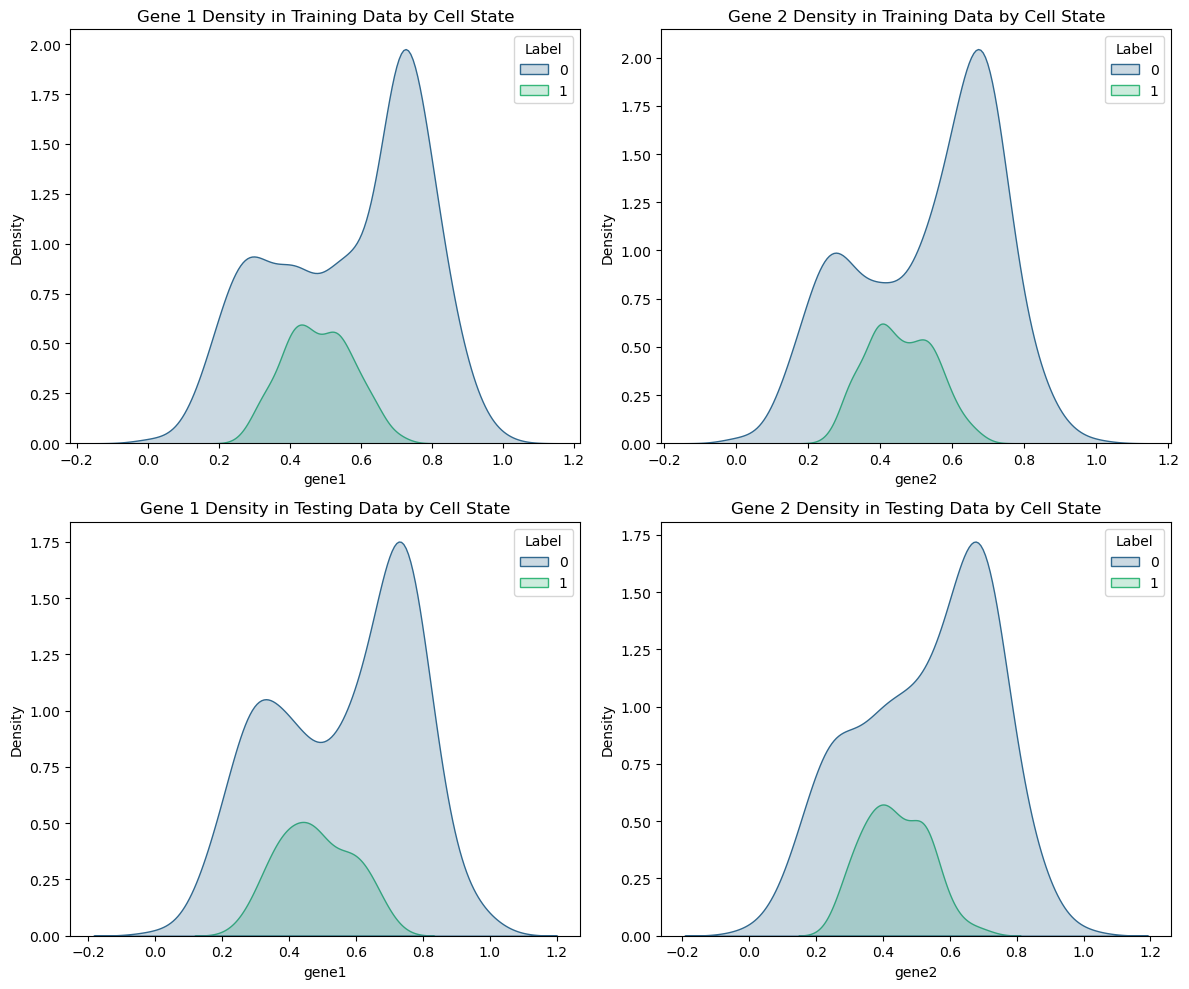

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

sns.kdeplot(data=train_plot_data, x='gene1', hue='Label', fill=True, palette='viridis', ax=ax[0,0])
ax[0,0].set_title('Gene 1 Density in Training Data by Cell State')
sns.kdeplot(data=train_plot_data, x='gene2', hue='Label', fill=True, palette='viridis', ax=ax[0,1])
ax[0,1].set_title('Gene 2 Density in Training Data by Cell State')
sns.kdeplot(data=test_plot_data, x='gene1', hue='Label', fill=True, palette='viridis', ax=ax[1,0])
ax[1,0].set_title('Gene 1 Density in Testing Data by Cell State')
sns.kdeplot(data=test_plot_data, x='gene2', hue='Label', fill=True, palette='viridis', ax=ax[1,1])
ax[1,1].set_title('Gene 2 Density in Testing Data by Cell State')

plt.tight_layout()
plt.show()

From the cell state histograms, it's clear that there is a class imbalance in both the training and testing datasets, with cell state 1 being the minority class. The scatterplots reveal a central cluster for cell state 1, surrounded by data points corresponding to cell state 0, indicating the need for an elliptical decision boundary for effective classification. To remedy the class imbalance, I believe that SMOTE will be an effective method because it will generate new samples of the minority class based on nearby neighbors and the scatterplot reveals that there is an obvious cluster for cell state 1. Also, the density plots show that while cell state 0 has a peak skewed towards higher gene expression values, potentially making the classification of higher values more reliable, there is significant overlap between the classes. This suggests that relying on a single gene feature may not be sufficient for accurately classifying cell state 1.  

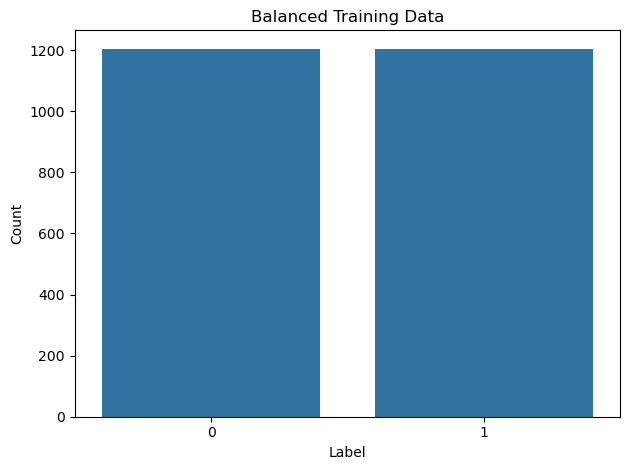

In [8]:
smote = SMOTE(random_state=24)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

y_train_balanced_df = pd.DataFrame({'Cell State':y_train_balanced})

sns.countplot(x='Cell State', data=y_train_balanced_df)
plt.title('Balanced Training Data')
plt.xlabel('Label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

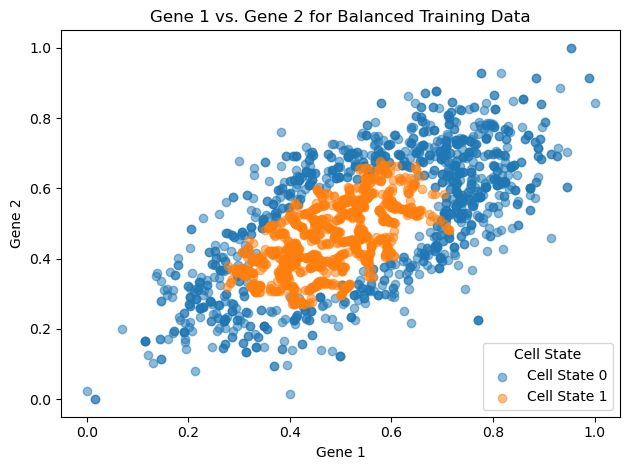

In [9]:
train_balanced_plot_data = X_train_balanced.copy()
train_balanced_plot_data['Label'] = y_train_balanced
train_balanced_plot_data = train_balanced_plot_data.reset_index()

for label in [0,1]:
    train_balanced_label_data = train_balanced_plot_data[train_balanced_plot_data['Label'] == label]
    plt.scatter(train_balanced_label_data['gene1'], train_balanced_label_data['gene2'], label=f'Cell State {label}', alpha=0.5)

plt.title("Gene 1 vs. Gene 2 for Balanced Training Data")
plt.xlabel('Gene 1')
plt.ylabel('Gene 2')
plt.legend(title='Cell State', loc='lower right')

plt.tight_layout()
plt.show()

Based on my observations, I do not expect logistic regression to perform well on this dataset because we clearly need some kind of elliptical decision boundary for effective classification when looking at the scatterplots, which logistic regression cannot do. On the other hand, I do expect an SVM to fit the data quite well because it can create the elliptical decision boundary that would fit this data. However, it is important to note that the choice of a non-linear kernel is crucial because if we use a linear kernel we will end up with a linear decision boundary which does not fit this data well. 

# *Part 2: Linear Classifier*

In [10]:
xx, yy = np.meshgrid(np.arange(0, 1.001, 0.001), np.arange(0, 1.001, 0.001))
X_contour = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['gene1', 'gene2'])
contour_predictions = {}

C_values = [0.001, 0.01, 0.1, 1, 10, 100000]
metrics = {'C': [], 'AUROC': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for C in C_values:
    model = LogisticRegression(C=C, penalty='l2', random_state=24)
    model.fit(X_train_balanced, y_train_balanced)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 
    y_contour = model.predict(X_contour)
    
    auroc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    contour_predictions[C] = y_contour
    
    metrics['C'].append(C)
    metrics['AUROC'].append(auroc)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1-Score'].append(f1)

model_no_reg = LogisticRegression(penalty=None, random_state=42)
model_no_reg.fit(X_train_balanced, y_train_balanced)

y_pred = model_no_reg.predict(X_test)
y_prob = model_no_reg.predict_proba(X_test)[:, 1]
y_contour = model_no_reg.predict(X_contour)

auroc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

contour_predictions['No Regularization'] = y_contour 

metrics['C'].append('No Regularization')
metrics['AUROC'].append(auroc)
metrics['Accuracy'].append(accuracy)
metrics['Precision'].append(precision)
metrics['Recall'].append(recall)
metrics['F1-Score'].append(f1)

metrics_df = pd.DataFrame(metrics)
metrics_df

,C,AUROC,Accuracy,Precision,Recall,F1-Score
0,0.001,0.669099,0.639889,0.267974,0.694915,0.386792
1,0.01,0.669099,0.639889,0.264901,0.677966,0.380952
2,0.1,0.668032,0.637119,0.266234,0.694915,0.384977
3,1,0.666180,0.639889,0.267974,0.694915,0.386792
4,10,0.665900,0.637119,0.266234,0.694915,0.384977
5,100000,0.666012,0.637119,0.266234,0.694915,0.384977
6,No Regularization,0.666012,0.637119,0.266234,0.694915,0.384977


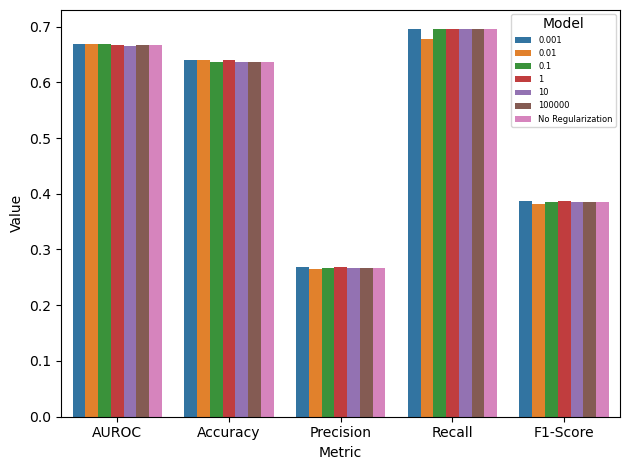

In [11]:
metrics_long = pd.melt(metrics_df, id_vars='C', 
                       value_vars=['AUROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
                       var_name='Metric', value_name='Value')

sns.barplot(x='Metric', y='Value', hue='C', data=metrics_long)
plt.legend(title='Model', loc='upper right', prop={'size': 6})
plt.tight_layout()
plt.show()

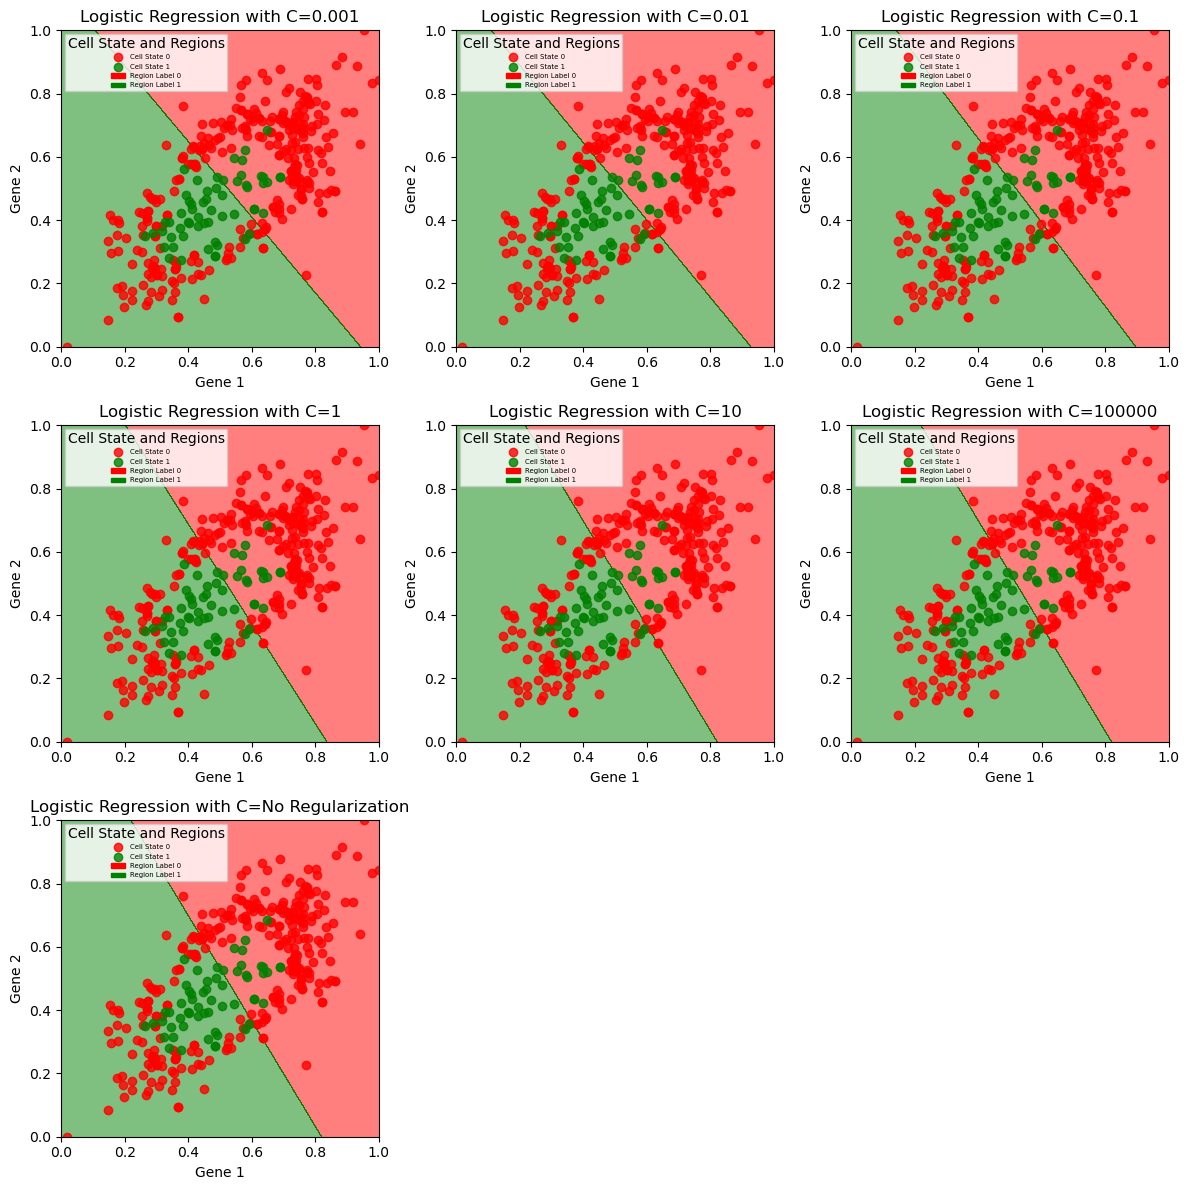

In [12]:
fig, ax = plt.subplots(3, 3, figsize=(12, 12)) 
ax = ax.ravel()
axis = 0

for C_value in contour_predictions:
    grid = contour_predictions[C_value].reshape(xx.shape)
    ax[axis].contourf(xx, yy, grid, cmap=ListedColormap(['red', 'green']), alpha=0.5)

    test_label_0 = test_plot_data[test_plot_data['Label'] == 0]
    scatter_0 = ax[axis].scatter(test_label_0['gene1'], test_label_0['gene2'], color='red', label='Cell State 0', alpha=0.8)
    
    test_label_1 = test_plot_data[test_plot_data['Label'] == 1]
    scatter_1 = ax[axis].scatter(test_label_1['gene1'], test_label_1['gene2'], color='green', label='Cell State 1', alpha=0.8)

    ax[axis].set_title(f'Logistic Regression with C={C_value}')
    ax[axis].set_xlabel('Gene 1')
    ax[axis].set_ylabel('Gene 2')    

    patch_0 = mpatches.Patch(color='red', label='Region Label 0')
    patch_1 = mpatches.Patch(color='green', label='Region Label 1')
    ax[axis].legend(handles=[scatter_0, scatter_1, patch_0, patch_1], title='Cell State and Regions', loc='upper left', prop={'size': 5})
    
    axis += 1

for i in range(axis, len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()

We can see from the plots above that as we increase the value of C (the inverse of the regularization strength), the decision boundary gets steeper. This is likely because as we increase C, we are creating a less 'strict' constraint on the regularized loss function which causes the coefficients to get larger as we continue to 'relax' the L2-constraint term. Furthermore, we can see that when C is very large, the decision boundary is almost identical to that of the logistic regression without any regularization. This is because if we are too relaxed with the constraint then it will essentially serve no purpose in regulating the coefficients as there is an increasingly good chance that the optimal coefficients actually fall within the constraint region. It is difficult to say which level results in the best fit over the others but looking at the performance metrics, I would have to say that C=0.001 seems to slightly outperform the other levels of regularization as it has a marginally better AUROC and accuracy than most other levels. However, I would not say that any of these logistic regression models fit the data well as the linear decision boundary is simply not flexible enough to capture then non-linear relationships in the data. 

# *Part 3: Linear SVM Classifiers* 

In [13]:
xx, yy = np.meshgrid(np.arange(0, 1.001, 0.001), np.arange(0, 1.001, 0.001))
X_contour = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['gene1', 'gene2'])
contour_predictions = {}

C_values = [0.001, 0.01, 0.1, 1, 10, 100000]
metrics = {'C': [], 'AUROC': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for C in C_values:
    model = SVC(C=C, kernel='linear', probability=True)
    model.fit(X_train_balanced, y_train_balanced)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 
    y_contour = model.predict(X_contour)
    
    auroc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    contour_predictions[C] = y_contour
    
    metrics['C'].append(C)
    metrics['AUROC'].append(auroc)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1-Score'].append(f1)

metrics_df = pd.DataFrame(metrics)
metrics_df

,C,AUROC,Accuracy,Precision,Recall,F1-Score
0,0.001,0.500000,0.537396,0.258929,0.983051,0.409894
1,0.010,0.668986,0.537396,0.258929,0.983051,0.409894
2,0.100,0.668397,0.609418,0.269663,0.813559,0.405063
3,1.000,0.667780,0.601108,0.265193,0.813559,0.400000
4,10.000,0.666882,0.601108,0.265193,0.813559,0.400000
5,100000.000,0.666770,0.601108,0.265193,0.813559,0.400000


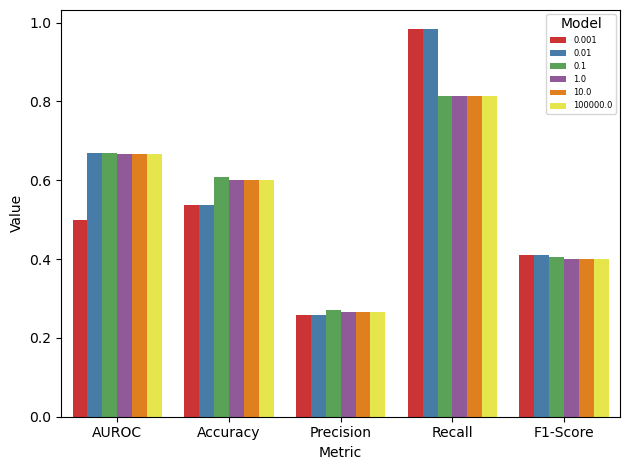

In [14]:
metrics_long = pd.melt(metrics_df, id_vars='C', 
                       value_vars=['AUROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
                       var_name='Metric', value_name='Value')

sns.barplot(x='Metric', y='Value', hue='C', data=metrics_long, palette='Set1')
plt.legend(title='Model', loc='upper right', prop={'size': 6})
plt.tight_layout()
plt.show()

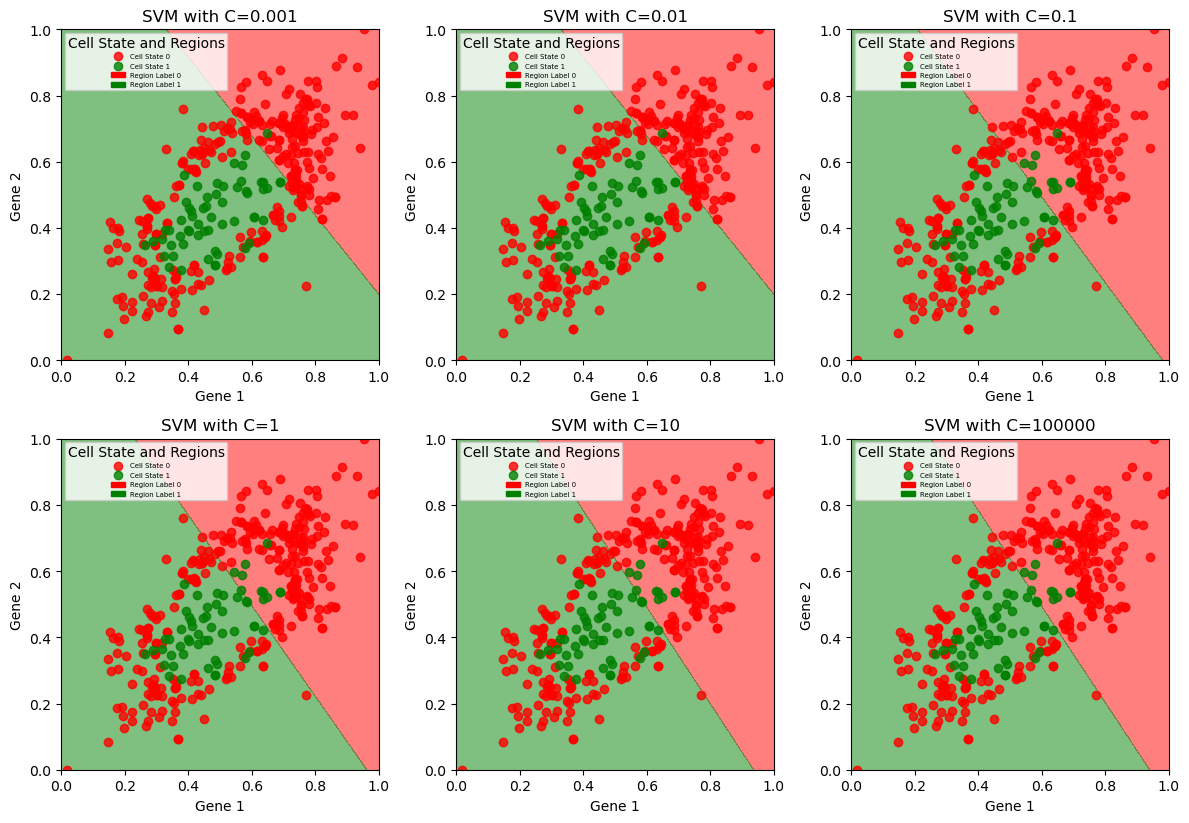

In [15]:
fig, ax = plt.subplots(3, 3, figsize=(12, 12)) 
ax = ax.ravel()
axis = 0

for C_value in contour_predictions:
    grid = contour_predictions[C_value].reshape(xx.shape)
    ax[axis].contourf(xx, yy, grid, levels=[-0.5, 0.5, 1.5], cmap=ListedColormap(['red', 'green']), alpha=0.5)

    test_label_0 = test_plot_data[test_plot_data['Label'] == 0]
    scatter_0 = ax[axis].scatter(test_label_0['gene1'], test_label_0['gene2'], color='red', label='Cell State 0', alpha=0.8)
    
    test_label_1 = test_plot_data[test_plot_data['Label'] == 1]
    scatter_1 = ax[axis].scatter(test_label_1['gene1'], test_label_1['gene2'], color='green', label='Cell State 1', alpha=0.8)

    ax[axis].set_title(f'SVM with C={C_value}')
    ax[axis].set_xlabel('Gene 1')
    ax[axis].set_ylabel('Gene 2')    

    patch_0 = mpatches.Patch(color='red', label='Region Label 0')
    patch_1 = mpatches.Patch(color='green', label='Region Label 1')
    ax[axis].legend(handles=[scatter_0, scatter_1, patch_0, patch_1], title='Cell State and Regions', loc='upper left', prop={'size': 5})
    
    axis += 1

for i in range(axis, len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()

Overall, the linear SVM performs worse than the logistic regression in all metrics other than the recall. When looking at the decision boundaries for the linear SVM models we can see that they tend to be closer to the top right of the scatterplot. This might be because there is a high concentration of cell state 0 samples in that region. However, similar to logistic regression, the linear decision boundary is not flexible enough to fit the data and thus linear SVM is still not a good model choice for this classification problem. 

# *Part 4: Kernel SVM Classifiers*

In [16]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

SVM_linear = SVC(kernel='linear')
SVM_poly = SVC(kernel='poly')
SVM_rbf = SVC(kernel='rbf')

grid_search_linear = GridSearchCV(SVM_linear, param_grid, cv=5, scoring='accuracy')
grid_search_poly = GridSearchCV(SVM_poly, param_grid, cv=5, scoring='accuracy')
grid_search_rbf = GridSearchCV(SVM_rbf, param_grid, cv=5, scoring='accuracy')

grid_search_linear.fit(X_train_balanced, y_train_balanced)
grid_search_poly.fit(X_train_balanced, y_train_balanced)
grid_search_rbf.fit(X_train_balanced, y_train_balanced)

print(f"Linear Kernel Best Parameters: {grid_search_linear.best_params_}")
print(f"Linear Kernel Best Cross-Validation Score: {grid_search_linear.best_score_}")
print('')

print(f"Polynomial Kernel Best Parameters: {grid_search_poly.best_params_}")
print(f"Polynomial Kernel Best Cross-Validation Score: {grid_search_poly.best_score_}")
print('')

print(f"RBF Kernel Best Parameters: {grid_search_rbf.best_params_}")
print(f"RBF Kernel Best Cross-Validation Score: {grid_search_rbf.best_score_}")
print('')

Linear Kernel Best Parameters: {'C': 0.001}
Linear Kernel Best Cross-Validation Score: 0.7161825726141079

Polynomial Kernel Best Parameters: {'C': 0.01}
Polynomial Kernel Best Cross-Validation Score: 0.846058091286307

RBF Kernel Best Parameters: {'C': 10}
RBF Kernel Best Cross-Validation Score: 0.9634854771784231



In [17]:
def svm_performance(model):
    xx, yy = np.meshgrid(np.arange(0, 1.001, 0.001), np.arange(0, 1.001, 0.001))
    X_contour = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['gene1', 'gene2'])
    
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 
    y_contour = model.predict(X_contour)

    auroc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return auroc, accuracy, precision, recall, f1, y_contour

In [18]:
linear_auroc, linear_accuracy, linear_precision, linear_recall, linear_f1, linear_y_contour = svm_performance(SVC(kernel='linear', C=0.001, probability=True))
poly_auroc, poly_accuracy, poly_precision, poly_recall, poly_f1, poly_y_contour = svm_performance(SVC(kernel='poly', C=0.001, probability=True))
rbf_auroc, rbf_accuracy, rbf_precision, rbf_recall, rbf_f1, rbf_y_contour = svm_performance(SVC(kernel='rbf', C=10, probability=True))

contour_predictions = {'Linear SVM': linear_y_contour, 'Polynomial SVM': poly_y_contour, 'RBF SVM': rbf_y_contour}
metrics = {'Model': ['Linear SVM', 'Polynomial SVM', 'RBF SVM'], 
           'AUROC': [linear_auroc, poly_auroc, rbf_auroc], 
           'Accuracy': [linear_accuracy, poly_accuracy, rbf_accuracy], 
           'Precision': [linear_precision, poly_precision, rbf_precision], 
           'Recall': [linear_recall, poly_recall, rbf_recall], 
           'F1-Score': [linear_f1, poly_f1, rbf_f1]}
metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,AUROC,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.500000,0.537396,0.258929,0.983051,0.409894
1,Polynomial SVM,0.776294,0.720222,0.358108,0.898305,0.512077
2,RBF SVM,0.974745,0.930748,0.750000,0.864407,0.803150


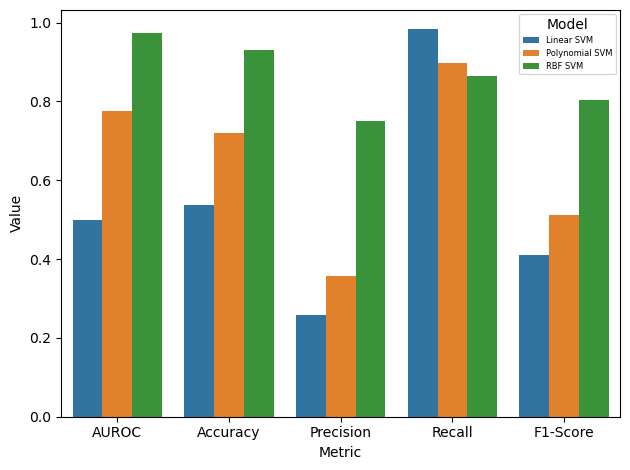

In [19]:
metrics_long = pd.melt(metrics_df, id_vars='Model', 
                       value_vars=['AUROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
                       var_name='Metric', value_name='Value')

sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_long)
plt.legend(title='Model', loc='upper right', prop={'size': 6})
plt.tight_layout()
plt.show()

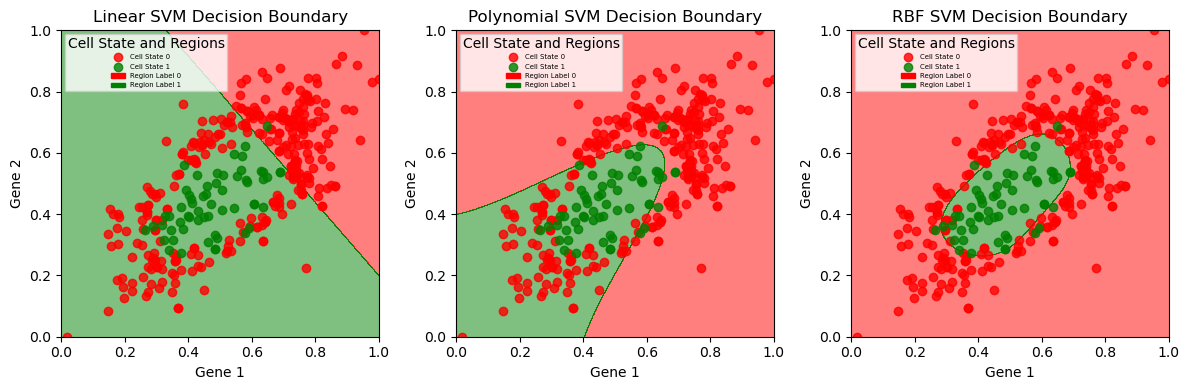

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4)) 
ax = ax.ravel()
axis = 0

for C_value in contour_predictions:
    grid = contour_predictions[C_value].reshape(xx.shape)
    ax[axis].contourf(xx, yy, grid, alpha=0.5, cmap=ListedColormap(['red', 'green']))

    test_label_0 = test_plot_data[test_plot_data['Label'] == 0]
    scatter_0 = ax[axis].scatter(test_label_0['gene1'], test_label_0['gene2'], color='red', label='Cell State 0', alpha=0.8)
    
    test_label_1 = test_plot_data[test_plot_data['Label'] == 1]
    scatter_1 = ax[axis].scatter(test_label_1['gene1'], test_label_1['gene2'], color='green', label='Cell State 1', alpha=0.8)

    ax[axis].set_title(f'{C_value} Decision Boundary')
    ax[axis].set_xlabel('Gene 1')
    ax[axis].set_ylabel('Gene 2')    

    patch_0 = mpatches.Patch(color='red', label='Region Label 0')
    patch_1 = mpatches.Patch(color='green', label='Region Label 1')
    ax[axis].legend(handles=[scatter_0, scatter_1, patch_0, patch_1], title='Cell State and Regions', loc='upper left', prop={'size': 5})
    
    axis += 1

for i in range(axis, len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()

For the linear SVM, we are seeing this decision boundary because the greatest linear margin between the classes can be found at the top right of the scatterplot. However, as we have seen, this linear decision boundary is not flexible enough to capture the complexity of the data. On the other hand, the polynomial SVM decision boundary is non-linear and fits the data much better than the linear SVM. However, it is not perfect because it is still constrained to a parabolic decision boundary due to being modeled with a third-degree polynomial. Finally, looking at the RBF SVM we can clearly see that this decision boundary fits the data the best by creating a complex, elliptical decision boundary. It is able to do this by using the kernel trick to transform the data into a higher dimensional space and create complex and non-linear decision boundaries that can capture much more complexity in the data then the linear and polynomial kernels. 